# Volatility Surfaces Demo
This notebook demonstrates the construction of SVI, SSVI, and Local Volatility surfaces using the pricing engine.

In [53]:
import sys
import os
# Add the parent directory to the path so we can import the kernel
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from kernel.market_data.volatility_surface import SVIVolatilitySurface, SSVIVolatilitySurface, LocalVolatilitySurface

class DummyRateCurve:
    def __init__(self, rate=0.05):
        self.rate = rate
    def get_rate(self, maturity: float) -> float:
        return self.rate * 100  # returns in percentage


In [54]:
# Generate dummy market data (option smile)
spot = 100.0
maturities = np.array([0.1, 0.25, 0.5, 1.0, 2.0, 3.0])
strikes = np.linspace(80, 120, 9)

data = []
for T in maturities:
    for K in strikes:
        moneyness = np.log(K / spot)
        # Create a basic smile shape
        vol = 0.20 + 0.05 * moneyness**2 + 0.01 * (1.0/T) * moneyness**2
        data.append({
            "Spot": spot,
            "Maturity": T,
            "Strike": K,
            "Implied Volatility": vol * 100
        })

option_data = pd.DataFrame(data)
rate_curve = DummyRateCurve(0.05)
option_data.head()


,Spot,Maturity,Strike,Implied Volatility
0,100.0,0.1,80.0,20.746896
1,100.0,0.1,85.0,20.396186
2,100.0,0.1,90.0,20.166513
3,100.0,0.1,95.0,20.039465
4,100.0,0.1,100.0,20.000000


In [55]:
# 1. SVI Volatility Surface
svi_surface = SVIVolatilitySurface(option_data, rate_curve)
svi_surface.calibrate_surface()
print(f"SVI Calibrated: {svi_surface.is_calibrated}")

# 2. SSVI Volatility Surface
ssvi_surface = SSVIVolatilitySurface(option_data, rate_curve)
ssvi_surface.calibrate_surface()
print(f"SSVI Calibrated: {ssvi_surface.is_calibrated}")

# 3. Local Volatility Surface (Using SVI as base)
local_surface = LocalVolatilitySurface(option_data, rate_curve, svi_surface)
print(f"Local Volatility Initialized: {local_surface.is_calibrated}")


SVI Calibrated: True
SSVI Calibrated: True
Local Volatility Initialized: True


In [56]:
def plot_surface(surface, title, option_data=None):
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    plot_maturities = np.linspace(0.1, 3.0, 30)
    plot_strikes = np.linspace(80, 120, 30)
    
    T, K = np.meshgrid(plot_maturities, plot_strikes)
    Z = np.zeros_like(T)
    
    for i in range(T.shape[0]):
        for j in range(T.shape[1]):
            Z[i, j] = surface.get_volatility(strike=K[i, j], maturity=T[i, j])
            
    surf = ax.plot_surface(K, T, Z, cmap='viridis', edgecolor='none', alpha=0.8)
    
    if option_data is not None:
        ax.scatter(option_data['Strike'], option_data['Maturity'], option_data['Implied Volatility'] / 100, color='red', s=20, label='Market Data')
        ax.legend()
        
    ax.set_xlabel('Strike')
    ax.set_ylabel('Maturity')
    ax.set_zlabel('Volatility')
    ax.set_title(title)
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()


Plotting SVI Volatility Surface...


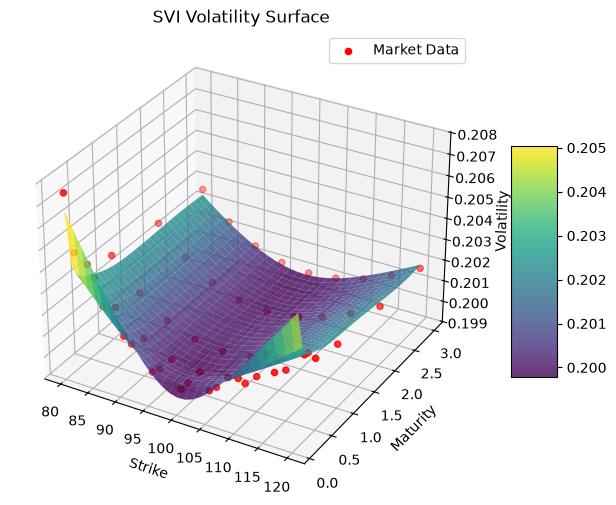

In [57]:
print("Plotting SVI Volatility Surface...")
plot_surface(svi_surface, "SVI Volatility Surface", option_data)


Plotting SSVI Volatility Surface...


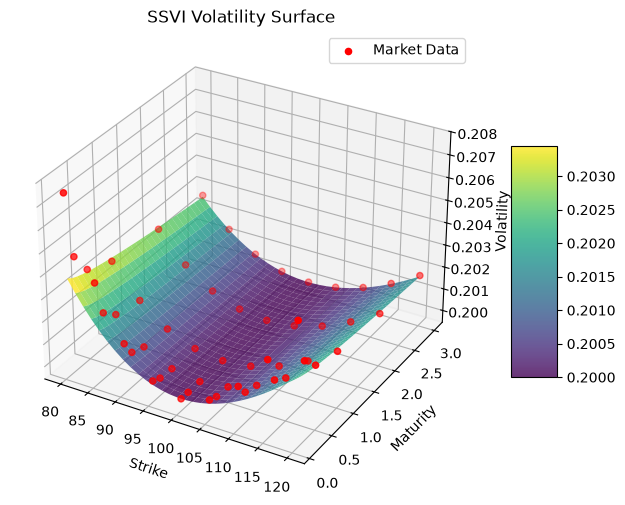

In [58]:
print("Plotting SSVI Volatility Surface...")
plot_surface(ssvi_surface, "SSVI Volatility Surface", option_data)


Plotting Local Volatility Surface...


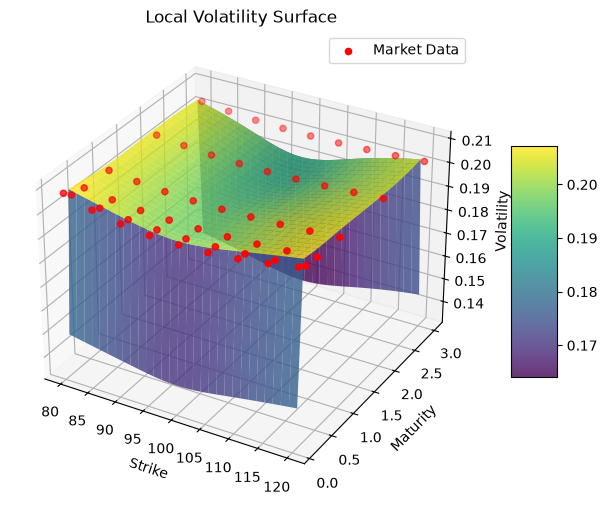

In [59]:
print("Plotting Local Volatility Surface...")
plot_surface(local_surface, "Local Volatility Surface", option_data)


## Real SPX Market Data
Below we use real SPX data from the pricing engine to re-create the surfaces.

In [60]:
from kernel.market_data.data_loader import MarketDataLoader
from kernel.market_data.market import Market
from kernel.market_data.volatility_surface.enums_volatility import VolatilitySurfaceType
from kernel.market_data.rate_curve_data.enums_interpolators import InterpolationType
from kernel.tools import CalendarConvention, ObservationFrequency, RateCurveType

data_loader = MarketDataLoader()
underlying_name = "SPX"
underlying_df = data_loader.get_underlying_info(underlying_name)
options_df = data_loader.get_option_data(underlying_name)
yield_df = data_loader.get_yield_curve(RateCurveType.RF_US_TREASURY.value)

market = Market(
    underlying_name=underlying_name,
    yield_curve_data=yield_df,
    underlying_data=underlying_df,
    option_data=options_df,
    rate_curve_type=RateCurveType.RF_US_TREASURY,
    interpolation_type=InterpolationType.CUBIC,
    volatility_surface_type=VolatilitySurfaceType.SVI,
    calendar_convention=CalendarConvention.ACT_360,
    obs_frequency=ObservationFrequency.ANNUAL,
)

real_option_data = options_df.copy()
real_option_data['Implied Volatility'] = real_option_data['Implied Volatility'].astype(float)
real_option_data['Strike'] = real_option_data['Strike'].astype(float)
real_option_data['Maturity'] = real_option_data['Maturity'].astype(str).apply(market._convert_maturities)
real_option_data['Spot'] = market.underlying_asset.last_price
real_rate_curve = market.rate_curve
print(f"Loaded {len(real_option_data)} option quotes for SPX.")


Loaded 324 option quotes for SPX.


In [61]:
# 1. SVI Volatility Surface
spx_svi_surface = SVIVolatilitySurface(real_option_data, real_rate_curve)
spx_svi_surface.calibrate_surface()
print(f"SPX SVI Calibrated: {spx_svi_surface.is_calibrated}")

# 2. SSVI Volatility Surface
spx_ssvi_surface = SSVIVolatilitySurface(real_option_data, real_rate_curve)
spx_ssvi_surface.calibrate_surface()
print(f"SPX SSVI Calibrated: {spx_ssvi_surface.is_calibrated}")

# 3. Local Volatility Surface (Using SVI as base)
spx_local_surface = LocalVolatilitySurface(real_option_data, real_rate_curve, spx_svi_surface)
print(f"SPX Local Volatility Initialized: {spx_local_surface.is_calibrated}")


SPX SVI Calibrated: True
SPX SSVI Calibrated: True
SPX Local Volatility Initialized: True


Plotting SPX SVI Volatility Surface...


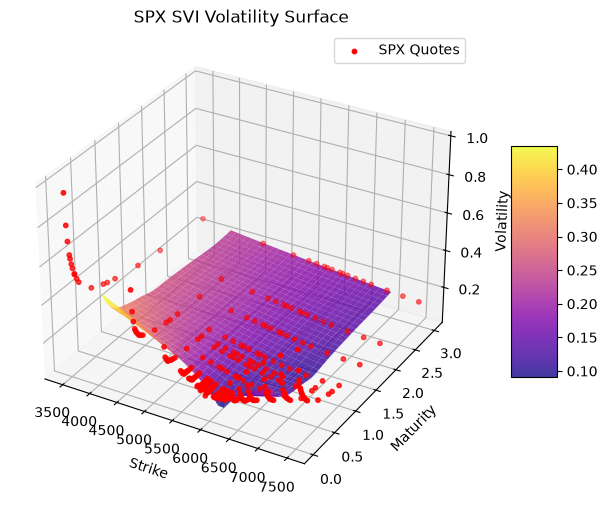

In [62]:
def plot_spx_surface(surface, title, option_data=None):
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    plot_maturities = np.linspace(0.1, 3.0, 30)
    plot_strikes = np.linspace(4000, 7000, 30)
    
    T, K = np.meshgrid(plot_maturities, plot_strikes)
    Z = np.zeros_like(T)
    
    for i in range(T.shape[0]):
        for j in range(T.shape[1]):
            Z[i, j] = surface.get_volatility(strike=K[i, j], maturity=T[i, j])
            
    surf = ax.plot_surface(K, T, Z, cmap='plasma', edgecolor='none', alpha=0.8)
    
    if option_data is not None:
        # Filter points to only show those inside our plot range to avoid breaking the view
        mask = (option_data['Strike'] >= 3000) & (option_data['Strike'] <= 8000) & (option_data['Maturity'] <= 3.5)
        filtered_data = option_data[mask]
        ax.scatter(filtered_data['Strike'], filtered_data['Maturity'], filtered_data['Implied Volatility'] / 100, color='red', s=10, label='SPX Quotes')
        ax.legend()
        
    ax.set_xlabel('Strike')
    ax.set_ylabel('Maturity')
    ax.set_zlabel('Volatility')
    ax.set_title(title)
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

print("Plotting SPX SVI Volatility Surface...")
plot_spx_surface(spx_svi_surface, "SPX SVI Volatility Surface", real_option_data)


Plotting SPX SSVI Volatility Surface...


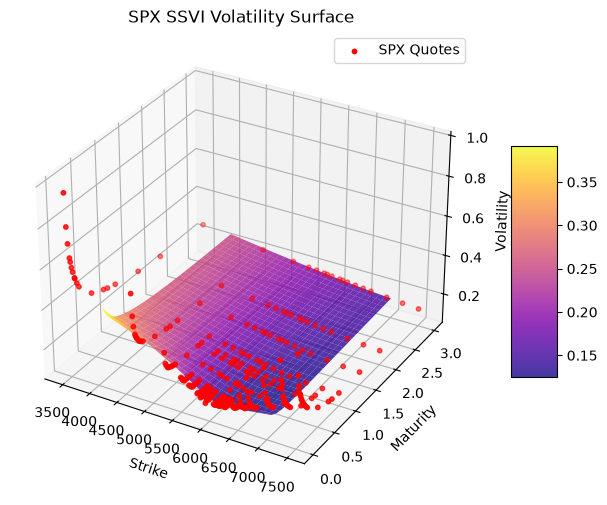

In [63]:
print("Plotting SPX SSVI Volatility Surface...")
plot_spx_surface(spx_ssvi_surface, "SPX SSVI Volatility Surface", real_option_data)


Plotting SPX Local Volatility Surface...


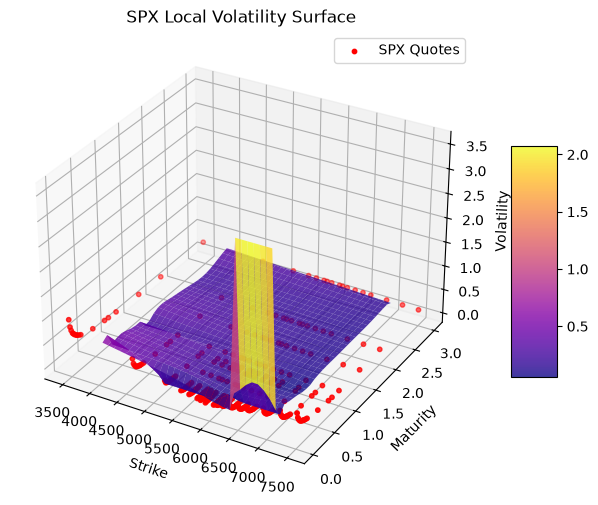

In [64]:
print("Plotting SPX Local Volatility Surface...")
plot_spx_surface(spx_local_surface, "SPX Local Volatility Surface", real_option_data)
